In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [4]:
np.random.seed(42)

num_samples = 500

years_of_experience = np.random.randint(2,21,size =num_samples)

slope=(200_000-60_000)/18
intercept = 60_000

salaries = slope * years_of_experience + intercept + np.random.normal(0,10_000, size=num_samples)


data = {'Years_of_Experience': years_of_experience,'Salary':salaries}

df = pd.DataFrame(data)

In [5]:
df.head()

,Years_of_Experience,Salary
0,8,115037.780010
1,16,182309.972927
2,12,156442.408989
3,9,144753.562169
4,8,130798.818454


In [6]:
df.describe()

,Years_of_Experience,Salary
count,500.000000,500.000000
mean,10.616000,142570.011096
std,5.662922,44935.263058
min,2.000000,54881.134555
25%,5.750000,104426.300731
50%,10.000000,139865.032545
75%,16.000000,182341.125962
max,20.000000,241879.376204


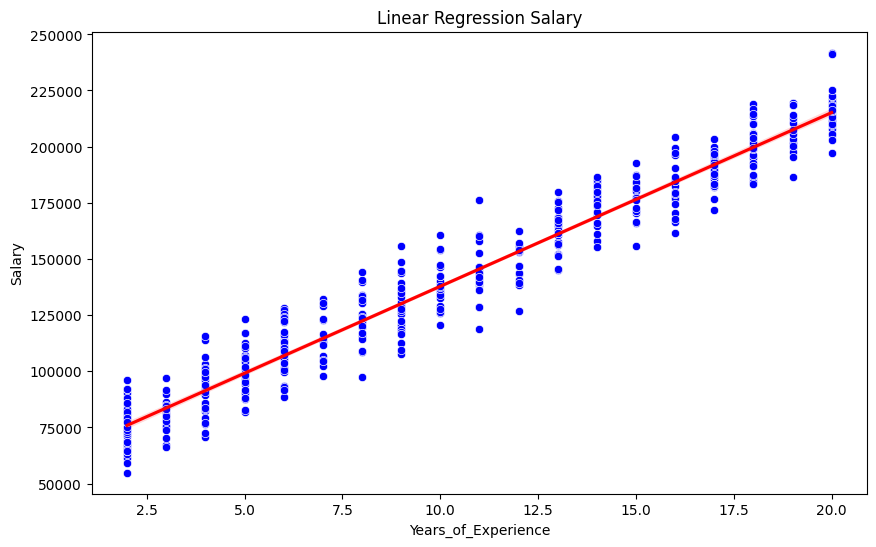

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Years_of_Experience',y='Salary',data=df,color='blue')
sns.regplot(x='Years_of_Experience',y='Salary',data=df,scatter=False,color='red')

plt.xlabel('Years_of_Experience')
plt.ylabel('Salary')
plt.title('Linear Regression Salary')

plt.show()

In [15]:
X = df[['Years_of_Experience']]
y = df[['Salary']]

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
lr = LinearRegression()

In [17]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
lr.score(X_train,y_train)

0.9488372177019488

In [19]:
lr.score(X_test,y_test)

0.9573704756930143

In [14]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [20]:
y_pred = lr.predict(X_test)

In [21]:
mean_absolute_error(y_test, y_pred)

7905.114728709234

In [22]:
mean_squared_error(y_test, y_pred)

93933277.37947096

In [23]:
r2_score(y_test, y_pred)

0.9573704756930143

In [24]:
lr.coef_

array([[7696.61292305]])

In [25]:
lr.intercept_

array([60961.34088028])

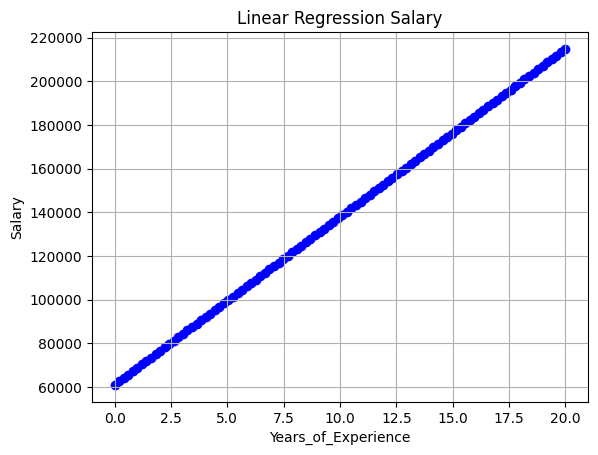

In [27]:
coefficients = lr.coef_
intercept = lr.intercept_

x = np.linspace(0,20,100)
y = coefficients * x + intercept
plt.scatter(x,y,label=f'y={coefficients[0]}x + {intercept}',color='blue')


plt.xlabel('Years_of_Experience')
plt.ylabel('Salary')
plt.title('Linear Regression Salary')

plt.grid()
plt.show()

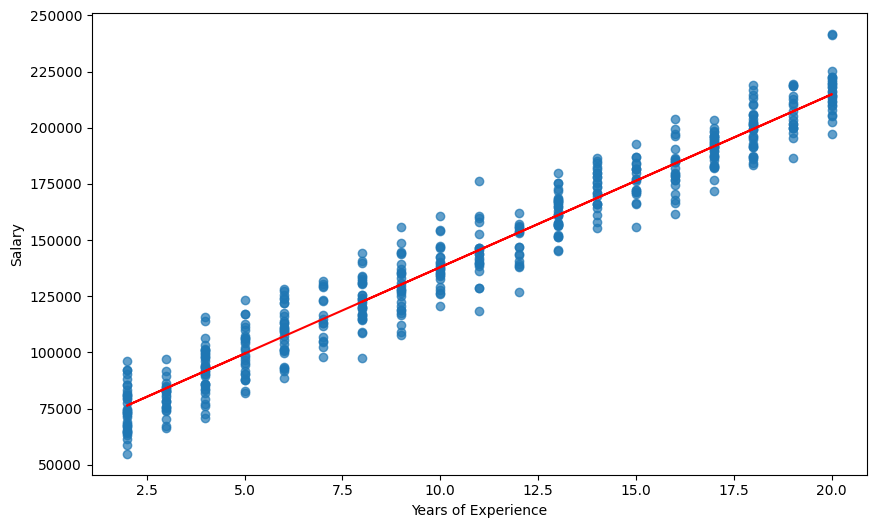

In [31]:
plt.figure(figsize=(10,6))

plt.scatter(df['Years_of_Experience'], df['Salary'], alpha=0.7)

plt.plot(
    df['Years_of_Experience'],
    lr.predict(df[['Years_of_Experience']]),
    color='red'
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

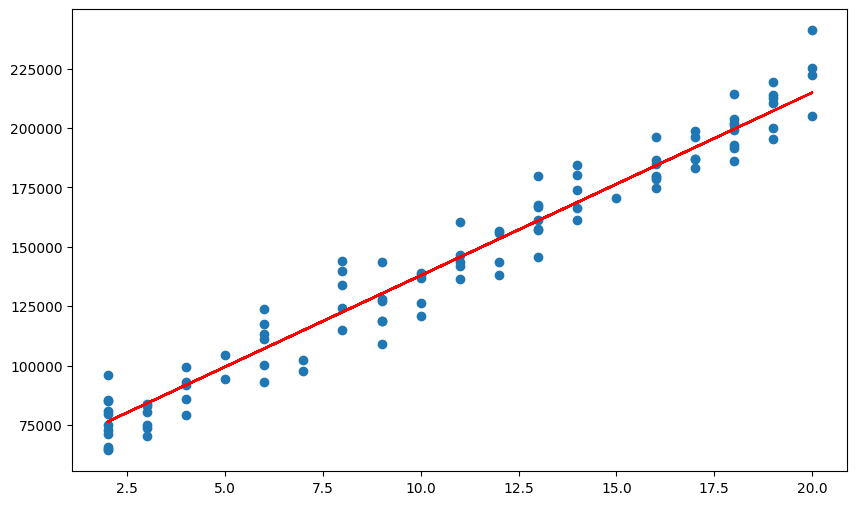

In [35]:
plt.figure(figsize=(10,6))

plt.scatter(x_test, y_test)

plt.plot(x_test, lr.predict(x_test), color="red")

plt.show()